<a href="https://colab.research.google.com/github/Priya-on-loop/CaseStudy_NLP/blob/main/nlp_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.0 MB/s eta 0:00:00


## Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import gensim
import gensim.downloader as api

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from sklearn.model_selection import GridSearchCV

import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.models import Model

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

from sklearn.metrics import average_precision_score


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## Read dataset

In [4]:
filepath = '/content/drive/MyDrive/AI  and ML/DataSets/Preprocessed_DonorsChoose_dataset.csv'
df_donor = pd.read_csv(filepath)
df_donor.head(8)

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0
5,p154343,mrs,fl,grades_3_5,literacy_language_specialneeds,literature_writing_specialneeds,1,1,113.22,11,flexible seating mrs jarvis terrific third gra...,moving 2nd grade 3rd grade beginning next scho...,students_need_movement_successful_variety_stud...,0
6,p099819,mrs,ct,grades_6_8,literacy_language_specialneeds,literacy_specialneeds,1,1,159.99,3,chromebooks special education reading program,students dynamic energetic group middle school...,students_need_dependable_laptops_daily_classro...,0
7,p092424,ms,ga,grades_3_5,math_science,mathematics,7,1,229.00,4,21st century,not students struggle poverty also learning ma...,students_need_ipads_help_access_world_online_r...,0


# EDA

## basic dataset understanding

In [5]:
df_donor.shape

(109248, 14)

In [6]:
df_donor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109248 entries, 0 to 109247
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            109248 non-null  object 
 1   teacher_prefix                                109248 non-null  object 
 2   school_state                                  109248 non-null  object 
 3   project_grade_category                        109248 non-null  object 
 4   project_subject_categories                    109248 non-null  object 
 5   project_subject_subcategories                 109248 non-null  object 
 6   teacher_number_of_previously_posted_projects  109248 non-null  int64  
 7   project_is_approved                           109248 non-null  int64  
 8   price                                         109248 non-null  float64
 9   quantity                                      10

In [7]:
df_donor.describe()

,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,isdigit_summary
count,109248.000000,109248.000000,109248.000000,109248.000000,109248.000000
mean,11.153165,0.848583,298.119343,16.965610,0.144222
std,27.777154,0.358456,367.498030,26.182942,0.351317
min,0.000000,0.000000,0.660000,1.000000,0.000000
25%,0.000000,1.000000,104.310000,4.000000,0.000000
50%,2.000000,1.000000,206.220000,9.000000,0.000000
75%,9.000000,1.000000,379.000000,21.000000,0.000000
max,451.000000,1.000000,9999.000000,930.000000,1.000000


In [8]:
df_donor.isnull().sum()

,0
id,0
teacher_prefix,0
school_state,0
project_grade_category,0
project_subject_categories,0
project_subject_subcategories,0
teacher_number_of_previously_posted_projects,0
project_is_approved,0
price,0
quantity,0


## View the text columns

In [9]:
df_donor['cleaned_titles'].head()

,cleaned_titles
0,educational support english learners home
1,wanted projector hungry learners
2,soccer equipment awesome middle school students
3,techie kindergarteners
4,interactive math tools


In [10]:
df_donor['cleaned_summary'].head()

,cleaned_summary
0,students_need_opportunities_practice_beginning...
1,students_need_projector_help_viewing_education...
2,students_need_shine_guards_athletic_socks_socc...
3,students_need_engage_reading_math_way_inspire_...
4,students_need_hands_practice_mathematics_fun_p...


In [11]:
df_donor['cleaned_essays'].head()

,cleaned_essays
0,students english learners working english seco...
1,students arrive school eager learn polite gene...
2,true champions not always ones win guts mia ha...
3,work unique school filled esl english second l...
4,second grade classroom next year made around 2...


## Check class balance

In [12]:
# our target column is 'project_is_approved'
df_donor['project_is_approved'].unique()

array([0, 1])

In [13]:
df_donor['project_is_approved'].value_counts()

,count
project_is_approved,
1,92706
0,16542


In [14]:
# inference
#--------------
# the data is imbalanced

# Preprocessing

### required columns

In [15]:
df_donor['text'] = (
    df_donor['cleaned_titles'] + " " +
    df_donor['cleaned_summary'] + " " +
    df_donor['cleaned_essays']
)
df_donor.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary,text
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0,educational support english learners home stud...
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0,wanted projector hungry learners students_need...
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0,soccer equipment awesome middle school student...
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0,techie kindergarteners students_need_engage_re...
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0,interactive math tools students_need_hands_pra...


## missing value handling

In [16]:
df_donor.isnull().sum() # no missisng values

,0
id,0
teacher_prefix,0
school_state,0
project_grade_category,0
project_subject_categories,0
project_subject_subcategories,0
teacher_number_of_previously_posted_projects,0
project_is_approved,0
price,0
quantity,0


# NLP Preprocessing

In [17]:

print(df_donor['text'][0])


educational support english learners home students_need_opportunities_practice_beginning_reading_skills_english_home students english learners working english second third languages melting pot refugees immigrants native born americans bringing gift language school 24 languages represented english learner program students every level mastery also 40 countries represented families within school student brings wealth knowledge experiences us open eyes new cultures beliefs respect limits language limits world ludwig wittgenstein english learner strong support system home begs resources many times parents learning read speak english along side children sometimes creates barriers parents able help child learn phonetics letter recognition reading skills providing dvd players students able continue mastery english language even no one home able assist families students within level 1 proficiency status offered part program educational videos specially chosen english learner teacher sent home 

In [18]:
# inference
# -------------------------
# the text has no punctuations and all of the text are already in lowercase

In [19]:
# The dataset used in this project is a preprocessed version of the DonorsChoose dataset.
#  The columns (cleaned_titles, cleaned_summary, and cleaned_essays) have already been converted
#  to lowercase and cleaned by removing punctuation, stop words, HTML tags, numbers, and special characters.

## Tokenization

In [20]:
df_donor['tokens'] = df_donor['text'].fillna('').apply(word_tokenize)
df_donor[['text', 'tokens']].head()

,text,tokens
0,educational support english learners home stud...,"[educational, support, english, learners, home..."
1,wanted projector hungry learners students_need...,"[wanted, projector, hungry, learners, students..."
2,soccer equipment awesome middle school student...,"[soccer, equipment, awesome, middle, school, s..."
3,techie kindergarteners students_need_engage_re...,"[techie, kindergarteners, students_need_engage..."
4,interactive math tools students_need_hands_pra...,"[interactive, math, tools, students_need_hands..."


## Lemmatization

In [21]:
lemmatizer = WordNetLemmatizer()

df_donor['lemmatized_tokens'] = df_donor['tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)
df_donor[['tokens', 'lemmatized_tokens']].head()

,tokens,lemmatized_tokens
0,"[educational, support, english, learners, home...","[educational, support, english, learner, home,..."
1,"[wanted, projector, hungry, learners, students...","[wanted, projector, hungry, learner, students_..."
2,"[soccer, equipment, awesome, middle, school, s...","[soccer, equipment, awesome, middle, school, s..."
3,"[techie, kindergarteners, students_need_engage...","[techie, kindergartener, students_need_engage_..."
4,"[interactive, math, tools, students_need_hands...","[interactive, math, tool, students_need_hands_..."


## Converting tokens back to text

In [22]:
df_donor['processed_text'] = df_donor['lemmatized_tokens'].apply(
    lambda words: " ".join(words)
)
df_donor[['processed_text']].head()

,processed_text
0,educational support english learner home stude...
1,wanted projector hungry learner students_need_...
2,soccer equipment awesome middle school student...
3,techie kindergartener students_need_engage_rea...
4,interactive math tool students_need_hands_prac...


In [23]:
# counting total words
all_words = " ".join(df_donor['processed_text']).split()

print("Total words:", len(all_words))

Total words: 15500965


In [24]:
# counting unique words
print("Unique words:", len(set(all_words)))

Unique words: 159675


## remove low-frequency words or phrases.

In [25]:
# most frequent words
from collections import Counter

word_freq = Counter(all_words)

word_freq.most_common(20)

[('student', 854053),
 ('school', 264465),
 ('learning', 186857),
 ('classroom', 183645),
 ('not', 138885),
 ('help', 135804),
 ('need', 134836),
 ('learn', 129074),
 ('many', 105487),
 ('work', 98633),
 ('reading', 94417),
 ('book', 89689),
 ('class', 86902),
 ('use', 84758),
 ('day', 81857),
 ('year', 81297),
 ('come', 81142),
 ('love', 80774),
 ('able', 75962),
 ('technology', 73266)]

In [26]:
# removing very rare words

word_counts = Counter(all_words)
df_donor['processed_text'] = df_donor['lemmatized_tokens'].apply(
    lambda words: " ".join(
        [word for word in words if word_counts[word] >= 2]
    )
)

# Word Embedding

## TF-IDF

### Unigram

In [27]:
tfidf_uni = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,1)
)

X_uni = tfidf_uni.fit_transform(df_donor["processed_text"])

In [28]:
y = df_donor['project_is_approved']
X_train, X_test, y_train, y_test = train_test_split(
    X_uni,
    y,
    test_size=0.2,
    random_state=42
)

lr_uni = LogisticRegression(max_iter=100)
lr_uni.fit(X_train, y_train)

pred_uni = lr_uni.predict(X_test)

acc_uni = accuracy_score(y_test, pred_uni)

### Bigram

In [29]:
tfidf_bi = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2)
)

X_bi = tfidf_bi.fit_transform(df_donor["processed_text"])

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bi,
    y,
    test_size=0.2,
    random_state=42
)

lr_bi = LogisticRegression(max_iter=100)
lr_bi.fit(X_train, y_train)

pred_bi = lr_bi.predict(X_test)

acc_bi = accuracy_score(y_test, pred_bi)

### Trigram

In [31]:
tfidf_tri = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,3)
)

X_tri = tfidf_tri.fit_transform(df_donor["processed_text"])

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tri,
    y,
    test_size=0.2,
    random_state=42
)

lr_tri = LogisticRegression(max_iter=100)
lr_tri.fit(X_train, y_train)

pred_tri = lr_tri.predict(X_test)

acc_tri = accuracy_score(y_test, pred_tri)

### Comparing

In [33]:
ngram_results = pd.DataFrame({
    "N-gram": ["Unigram", "Bigram", "Trigram"],
    "Accuracy": [acc_uni, acc_bi, acc_tri]
})

ngram_results

,N-gram,Accuracy
0,Unigram,0.850755
1,Bigram,0.849565
2,Trigram,0.850481


## custom word2vec model

In [34]:
from gensim.models import Word2Vec
sentences=df_donor['lemmatized_tokens']
word2vec_model = Word2Vec(
    sentences,
    vector_size=25,
    window=2,
    min_count=10,
    workers=4,
    epochs=3
)

In [35]:
# Convert Each Sentence to a Vector
def sentence_vector(words, model):
    vectors = [model.wv[word] for word in words if word in model.wv]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

X_word2vec = np.array(
    [sentence_vector(words, word2vec_model) for words in sentences]
)

y = df_donor['project_is_approved']

In [36]:
# train test split
X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(
    X_word2vec,
    y,
    test_size=0.2,
    random_state=42
)

## pretrained word2vec

In [37]:
pretrained_model = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


In [38]:
# Convert Each Sentence to a Vector
def document_vector(text):

    words = text.split()

    word_vectors = []

    for word in words:
        if word in pretrained_model:
            word_vectors.append(pretrained_model[word])

    if len(word_vectors) == 0:
        return np.zeros(pretrained_model.vector_size)

    return np.mean(word_vectors, axis=0)

In [39]:
X_pretrained = np.array(
    df_donor["processed_text"].apply(document_vector).tolist()
)

In [40]:
# splitting
X_train_pre, X_test_pre, y_train, y_test = train_test_split(
    X_pretrained,
    y,
    test_size=0.2,
    random_state=42
)

# Models

## Classical ML models

### Logistic Regression

In [41]:

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8504805491990847

Classification Report

              precision    recall  f1-score   support

           0       0.58      0.05      0.09      3316
           1       0.85      0.99      0.92     18534

    accuracy                           0.85     21850
   macro avg       0.72      0.52      0.51     21850
weighted avg       0.81      0.85      0.79     21850


Confusion Matrix

[[  170  3146]
 [  121 18413]]


### Naive Bayes

In [42]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_nb))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8482379862700229

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3316
           1       0.85      1.00      0.92     18534

    accuracy                           0.85     21850
   macro avg       0.42      0.50      0.46     21850
weighted avg       0.72      0.85      0.78     21850


Confusion Matrix

[[    0  3316]
 [    0 18534]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Random Forest

In [43]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8482379862700229

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3316
           1       0.85      1.00      0.92     18534

    accuracy                           0.85     21850
   macro avg       0.42      0.50      0.46     21850
weighted avg       0.72      0.85      0.78     21850


Confusion Matrix

[[    0  3316]
 [    0 18534]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### SVM

In [44]:
svm = LinearSVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.8494736842105263

Classification Report

              precision    recall  f1-score   support

           0       0.58      0.03      0.06      3316
           1       0.85      1.00      0.92     18534

    accuracy                           0.85     21850
   macro avg       0.72      0.51      0.49     21850
weighted avg       0.81      0.85      0.79     21850


Confusion Matrix

[[   99  3217]
 [   72 18462]]


### Compare Model

In [45]:
accuracy = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm)
}

comparison = pd.DataFrame(
    accuracy.items(),
    columns=["Model", "Accuracy"]
)

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
0,Logistic Regression,0.850481
3,SVM,0.849474
1,Naive Bayes,0.848238
2,Random Forest,0.848238


### Accuracy Bar Graph

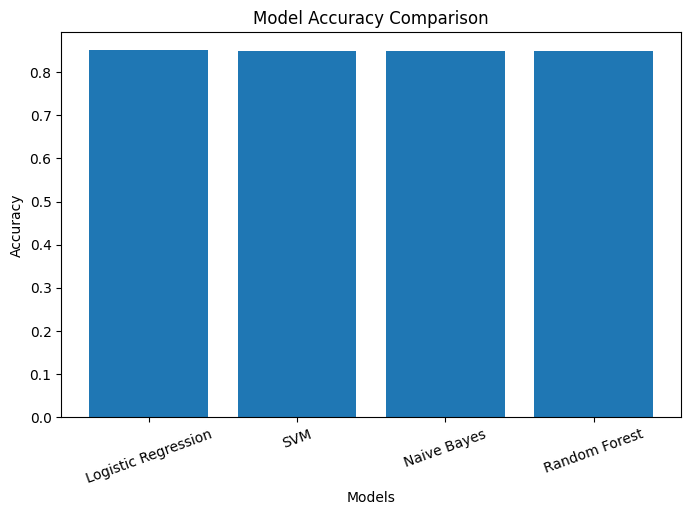

In [46]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

## Word2Vec Model

### Logistic Regression on Word2Vec

In [47]:
lr_w2v = LogisticRegression(max_iter=1000)

lr_w2v.fit(X_train_w2v, y_train)

pred = lr_w2v.predict(X_test_w2v)

print("Word2Vec + Logistic Regression Accuracy:", accuracy_score(y_test, pred))

Word2Vec + Logistic Regression Accuracy: 0.8483295194508009


### Final Comparison Table

In [48]:
comparison["Word2Vec + Logistic Regression"] = accuracy_score(y_test, pred)

print(comparison)

                 Model  Accuracy  Word2Vec + Logistic Regression
0  Logistic Regression  0.850481                         0.84833
3                  SVM  0.849474                         0.84833
1          Naive Bayes  0.848238                         0.84833
2        Random Forest  0.848238                         0.84833


# Hyperparameter Tuning GridSearchCV


## Logistic Regression

In [49]:
param_grid = {
    'C':[0.01,0.1,1,10]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=100),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_lr.fit(X_train,y_train)

print("Best Parameters:",grid_lr.best_params_)
print("Best Score:",grid_lr.best_score_)

Best Parameters: {'C': 1}
Best Score: 0.8500080146649949


## SVM

In [50]:
param_grid = {
    'C':[0.1,1,10]
}

grid_svm = GridSearchCV(
    LinearSVC(),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_svm.fit(X_train,y_train)

print(grid_svm.best_params_)
print(grid_svm.best_score_)

{'C': 0.1}
0.8493100532149217


## Naive Bayes

In [51]:
param_grid = {
    'alpha':[0.1,1,10]
}

grid_nb = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_nb.fit(X_train,y_train)

print(grid_nb.best_params_)
print(grid_nb.best_score_)

{'alpha': 0.1}
0.8486693061559878


# Building Functional API Model

In [52]:
X_train_tfidf, X_test_tfidf, X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(
    X_uni,
    X_word2vec,
    y,
    test_size=0.2,
    random_state=42
)

X_train_tfidf = X_train_tfidf.toarray()
X_test_tfidf = X_test_tfidf.toarray()

In [53]:
tfidf_input = Input(shape=(X_train_tfidf.shape[1],), name="TFIDF_Input")

x1 = Dense(256, activation='relu')(tfidf_input)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.3)(x1)

x1 = Dense(128, activation='relu')(x1)
x1 = BatchNormalization()(x1)

In [54]:
w2v_input = Input(shape=(X_train_w2v.shape[1],), name="Word2Vec_Input")

x2 = Dense(128, activation='relu')(w2v_input)
x2 = BatchNormalization()(x2)
x2 = Dropout(0.3)(x2)

x2 = Dense(64, activation='relu')(x2)
x2 = BatchNormalization()(x2)

In [55]:
merged = Concatenate()([x1, x2])

merged = Dense(128, activation='relu')(merged)
merged = BatchNormalization()(merged)
merged = Dropout(0.3)(merged)

merged = Dense(64, activation='relu')(merged)
merged = BatchNormalization()(merged)

output = Dense(1, activation='sigmoid')(merged)

In [56]:
model = Model(
    inputs=[tfidf_input, w2v_input],
    outputs=output
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ TFIDF_Input         │ (None, 3000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Word2Vec_Input      │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    768,256 │ TFIDF_Input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │      3,328 │ Word2Vec_Input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     24,704 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 848,833 (3.24 MB)

 Trainable params: 847,297 (3.23 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [57]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [58]:
# training the model
history = model.fit(
    [X_train_tfidf, X_train_w2v],
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.8253 - loss: 0.4368 - val_accuracy: 0.8493 - val_loss: 0.3868
Epoch 2/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8497 - loss: 0.3748 - val_accuracy: 0.8548 - val_loss: 0.3798
Epoch 3/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8575 - loss: 0.3493 - val_accuracy: 0.8495 - val_loss: 0.3902
Epoch 4/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8824 - loss: 0.2888 - val_accuracy: 0.8399 - val_loss: 0.4206
Epoch 5/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9222 - loss: 0.2020 - val_accuracy: 0.8401 - val_loss: 0.5113
Epoch 6/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9457 - loss: 0.1461 - val_accuracy: 0.8362 - val_loss: 0.5732
Epoch 7/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9598 - loss: 0.1121 - val_accuracy: 0.8354 - val_loss: 0.6548
Epoch 8/10
1093/1093 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9666 - loss: 0.0951 

In [59]:
loss, accuracy = model.evaluate(
    [X_test_tfidf, X_test_w2v],
    y_test
)

print("Test Accuracy:", accuracy)

683/683 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8277 - loss: 0.7710
Test Accuracy: 0.8277345299720764


In [60]:
# prediction
pred = model.predict(
    [X_test_tfidf, X_test_w2v]
)

pred = (pred > 0.5).astype(int)

683/683 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


In [61]:
# classification report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.37      0.19      0.25      3316
           1       0.87      0.94      0.90     18534

    accuracy                           0.83     21850
   macro avg       0.62      0.57      0.58     21850
weighted avg       0.79      0.83      0.80     21850



## Confusion Matrix

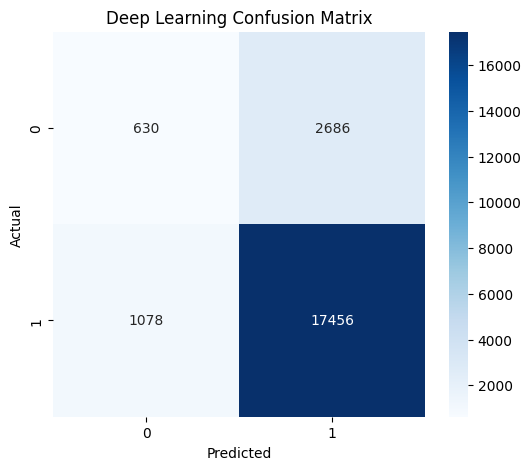

In [62]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Deep Learning Confusion Matrix")
plt.show()

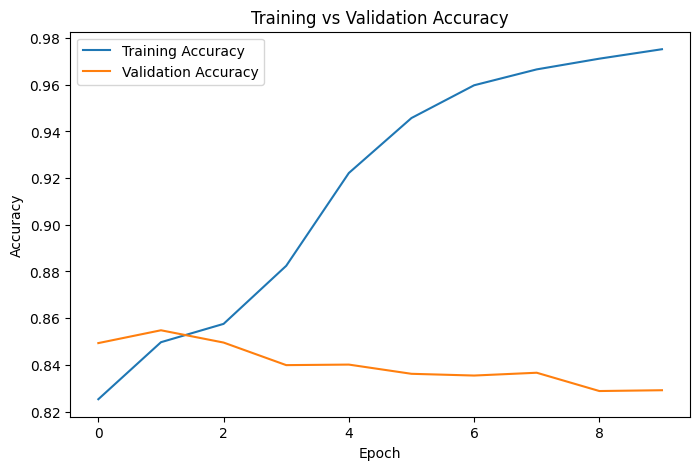

In [63]:
# plotting training vs validation accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

## ROC Curve

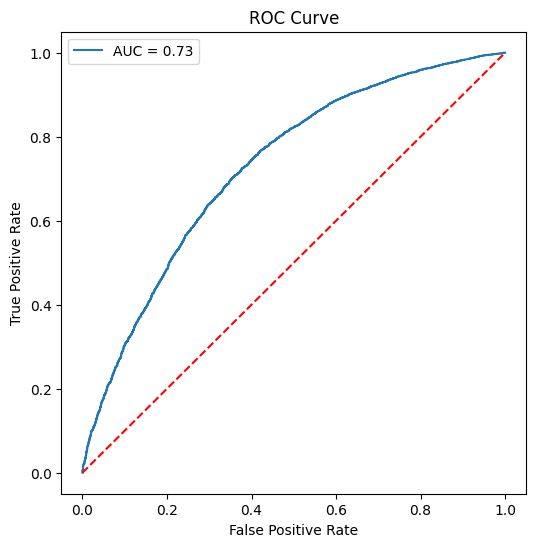

In [64]:
y_score = lr.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,y_score)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,label='AUC = %0.2f'%roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Precision Recall Curve

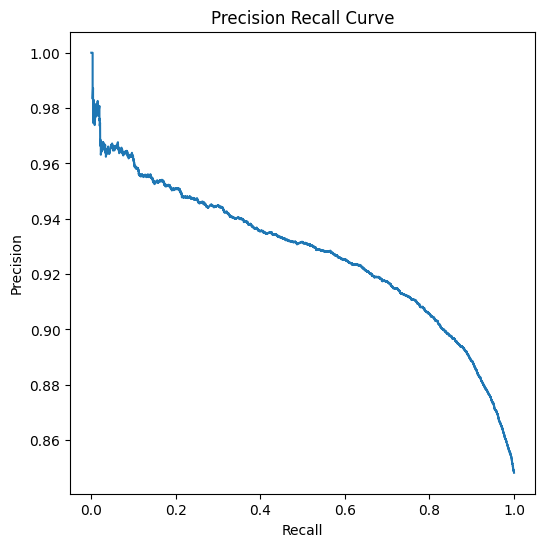

In [65]:
precision,recall,_ = precision_recall_curve(y_test,y_score)

plt.figure(figsize=(6,6))
plt.plot(recall,precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.show()

# Comparison and Analysis

## Comparison table

In [66]:
lr_test_acc = accuracy_score(y_test, y_pred_lr)
nb_test_acc = accuracy_score(y_test, y_pred_nb)
svm_test_acc = accuracy_score(y_test, y_pred_svm)
functional_test_acc = accuracy

lr_val_acc = grid_lr.best_score_
nb_val_acc = grid_nb.best_score_
svm_val_acc = grid_svm.best_score_
functional_val_acc = history.history['val_accuracy'][-1]

comparison = pd.DataFrame({
    "Category": [
        "Classical ML",
        "Classical ML",
        "Classical ML",
        "Deep Learning"
    ],
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "SVM",
        "Functional NN (TF-IDF + Word2Vec)"
    ],
    "Validation Accuracy": [
        lr_val_acc,
        nb_val_acc,
        svm_val_acc,
        functional_val_acc
    ],
    "Test Accuracy": [
        lr_test_acc,
        nb_test_acc,
        svm_test_acc,
        functional_test_acc
    ]
})

comparison.sort_values(by="Test Accuracy", ascending=False)

,Category,Model,Validation Accuracy,Test Accuracy
0,Classical ML,Logistic Regression,0.850008,0.850481
2,Classical ML,SVM,0.849310,0.849474
1,Classical ML,Naive Bayes,0.848669,0.848238
3,Deep Learning,Functional NN (TF-IDF + Word2Vec),0.829119,0.827735


## Confusion Matrix

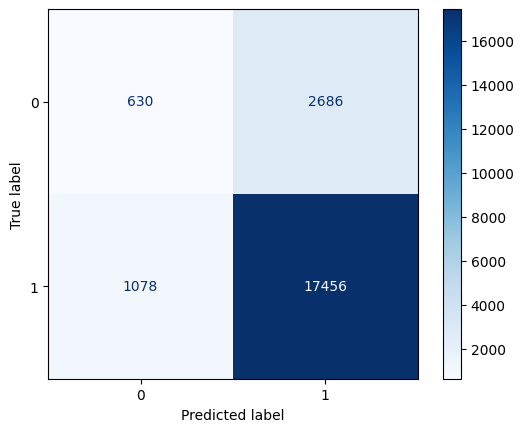

In [67]:
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.show()

## ROC plot

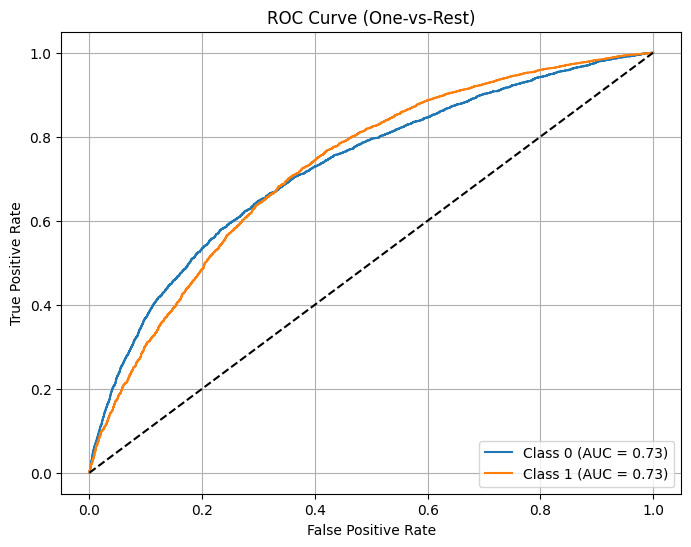

In [68]:
import numpy as np

# Emotion labels (classes are 0 and 1)
classes = np.unique(y_test)

# probability predictions from the Logistic Regression model for both classes
y_pred_prob = lr.predict_proba(X_test)

plt.figure(figsize=(8,6))

# Plot ROC curve for each class (one-vs-rest)
for i, class_label in enumerate(classes):
    if class_label == 0: # For class 0
        # Treating class 0 as positive, so invert y_test for true labels
        fpr, tpr, _ = roc_curve(1 - y_test, y_pred_prob[:, 0])
    else: # For class 1
        # Treating class 1 as positive
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob[:, 1])

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {class_label} (AUC = {roc_auc:.2f})"
    )

plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

## Precision–Recall Curve

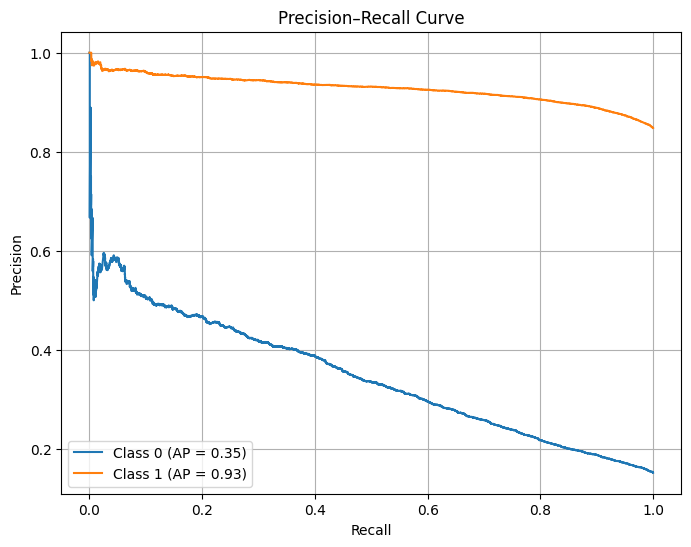

In [69]:
plt.figure(figsize=(8,6))


for i, class_label in enumerate(classes):
    if class_label == 0:
        precision, recall, _ = precision_recall_curve(
            1 - y_test,
            y_pred_prob[:, 0]
        )
        ap = average_precision_score(1 - y_test, y_pred_prob[:, 0])
    else:
        precision, recall, _ = precision_recall_curve(
            y_test,
            y_pred_prob[:, 1]
        )
        ap = average_precision_score(y_test, y_pred_prob[:, 1])

    plt.plot(
        recall,
        precision,
        label=f"Class {class_label} (AP = {ap:.2f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="lower left")
plt.grid(True)

plt.show()

# Model performance analysis

Support Vector Machine (SVM)
- Performed best among the classical models.
- Works well with high-dimensional TF-IDF features.

Logistic Regression
- Gave good results.
- Simple, fast, and effective for text classification.

Naive Bayes
- Showed moderate performance.
- Assumes words are independent, which is not always true.

Random Forest
- Performed lower than the other models.
- Not well suited for sparse text data.

Functional Neural Network
- Combined TF-IDF and Word2Vec features.
- Learned both important words and their meanings, improving classification.

#Potential Improvements

- Train for more epochs using Early Stopping.
- Tune model parameters (learning rate, batch size, etc.).
- Use Batch Normalization.
- Use a larger and more balanced dataset.

##